## Assignment 7 — Sequential Agentic Workflow using LangGraph

### Use Case 1: Telecom SIM Activation & Fraud Verification

In [2]:
!pip install -q langgraph langchain langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.7 MB/s eta 0:00:00


In [29]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain_core.messages import HumanMessage
import os
from google.colab import userdata
from IPython.display import Image


In [30]:
# CONFIGURE GEMINI API
# Set your Gemini API Key

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [31]:
#State definition
class TelecomState(TypedDict):
    customer_name: str
    aadhaar_status: str
    pan_status: str
    location: str
    previous_sim_requests: int

    kyc_result: str
    fraud_risk: str
    final_decision: str

In [32]:
# STEP 1 — KYC VERIFICATION TOOL
@tool
def kyc_verification_tool(
    aadhaar_status: str,
    pan_status: str
) -> str:
    """
    Validates customer Aadhaar and PAN verification status.
    """

    if aadhaar_status == "VALID" and pan_status == "VALID":
        return "VERIFIED"

    elif aadhaar_status == "PENDING" or pan_status == "PENDING":
        return "PENDING_VERIFICATION"

    else:
        return "INVALID_DOCUMENT"

In [38]:
def kyc_node(state: TelecomState):

    print("\n========== STEP 1 : KYC VERIFICATION ==========")

    result = kyc_verification_tool.invoke({
        "aadhaar_status": state["aadhaar_status"],
        "pan_status": state["pan_status"]
    })

    print(f"KYC RESULT : {result}")

    return {
        "kyc_result": result
    }

In [33]:
# STEP 2 — FRAUD DETECTION USING GEMINI
def fraud_detection_node(state: TelecomState):

    print("\n========== STEP 2 : FRAUD DETECTION ==========")

    prompt = f"""
    You are a telecom fraud detection AI.

    Analyze the following customer data:

    Customer Location: {state['location']}
    Previous SIM Requests: {state['previous_sim_requests']}
    KYC Status: {state['kyc_result']}

    Fraud Risk Categories:
    - LOW_RISK
    - MEDIUM_RISK
    - HIGH_RISK

    Rules:
    - Invalid KYC should be HIGH_RISK
    - Too many SIM requests should increase risk
    - Suspicious locations increase risk

    Return ONLY one category:
    LOW_RISK or MEDIUM_RISK or HIGH_RISK
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    risk = response.content.strip()

    print(f"FRAUD RISK : {risk}")

    return {
        "fraud_risk": risk
    }


In [34]:
# STEP 3 — FINAL ACTIVATION DECISION
def activation_decision_node(state: TelecomState):

    print("\n========== STEP 3 : FINAL DECISION ==========")

    risk = state["fraud_risk"]

    if risk == "LOW_RISK":
        decision = "SIM ACTIVATED"

    elif risk == "MEDIUM_RISK":
        decision = "MANUAL REVIEW REQUIRED"

    else:
        decision = "APPLICATION REJECTED"

    print(f"FINAL DECISION : {decision}")

    return {
        "final_decision": decision
    }


In [40]:
from langgraph import graph
# BUILD LANGGRAPH WORKFLOW

graph = StateGraph(TelecomState)

# Add Nodes
graph.add_node("kyc_verification", kyc_node)
graph.add_node("fraud_detection", fraud_detection_node)
graph.add_node("activation_decision", activation_decision_node)

# Define Sequential Flow
graph.set_entry_point("kyc_verification")

graph.add_edge("kyc_verification", "fraud_detection")
graph.add_edge("fraud_detection", "activation_decision")
graph.add_edge("activation_decision", END)

# Compile Graph
workflow = graph.compile()

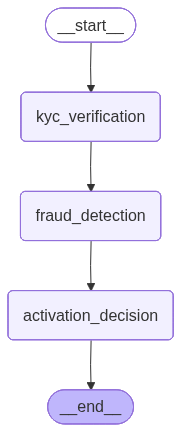

In [41]:
workflow

In [42]:
# TEST INPUT

customer_data = {
    "customer_name": "Rahul Sharma",
    "aadhaar_status": "VALID",
    "pan_status": "VALID",
    "location": "Bangalore",
    "previous_sim_requests": 1
}

# EXECUTE WORKFLOW

result = workflow.invoke(customer_data)

# FINAL OUTPUT

print("\n\n=========== FINAL WORKFLOW OUTPUT ===========")

for key, value in result.items():
    print(f"{key} : {value}")


========== STEP 1 : KYC VERIFICATION ==========
KYC RESULT : VERIFIED

========== STEP 2 : FRAUD DETECTION ==========
FRAUD RISK : LOW_RISK

========== STEP 3 : FINAL DECISION ==========
FINAL DECISION : SIM ACTIVATED


=========== FINAL WORKFLOW OUTPUT ===========
customer_name : Rahul Sharma
aadhaar_status : VALID
pan_status : VALID
location : Bangalore
previous_sim_requests : 1
kyc_result : VERIFIED
fraud_risk : LOW_RISK
final_decision : SIM ACTIVATED


In [43]:
customer_2 = {
    "customer_name": "Remya",
    "aadhaar_status": "VALID",
    "pan_status": "VALID",
    "location": "Kochi",
    "previous_sim_requests": 5
}

result_2 = workflow.invoke(customer_2)

print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_2.items():
    print(f"{key} : {value}")


========== STEP 1 : KYC VERIFICATION ==========
KYC RESULT : VERIFIED

========== STEP 2 : FRAUD DETECTION ==========
FRAUD RISK : MEDIUM_RISK

========== STEP 3 : FINAL DECISION ==========
FINAL DECISION : MANUAL REVIEW REQUIRED

========== FINAL WORKFLOW OUTPUT ==========
customer_name : Remya
aadhaar_status : VALID
pan_status : VALID
location : Kochi
previous_sim_requests : 5
kyc_result : VERIFIED
fraud_risk : MEDIUM_RISK
final_decision : MANUAL REVIEW REQUIRED


In [44]:
customer_3 = {
    "customer_name": "Rakesh Kumar",
    "aadhaar_status": "INVALID",
    "pan_status": "VALID",
    "location": "Unknown Border Area",
    "previous_sim_requests": 8
}

result_3 = workflow.invoke(customer_3)
print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_3.items():
    print(f"{key} : {value}")


========== STEP 1 : KYC VERIFICATION ==========
KYC RESULT : INVALID_DOCUMENT

========== STEP 2 : FRAUD DETECTION ==========
FRAUD RISK : HIGH_RISK

========== STEP 3 : FINAL DECISION ==========
FINAL DECISION : APPLICATION REJECTED

========== FINAL WORKFLOW OUTPUT ==========
customer_name : Rakesh Kumar
aadhaar_status : INVALID
pan_status : VALID
location : Unknown Border Area
previous_sim_requests : 8
kyc_result : INVALID_DOCUMENT
fraud_risk : HIGH_RISK
final_decision : APPLICATION REJECTED


In [45]:
customer_4 = {
    "customer_name": "Karan Mehta",
    "aadhaar_status": "PENDING",
    "pan_status": "VALID",
    "location": "Mumbai",
    "previous_sim_requests": 2
}

result_4 = workflow.invoke(customer_4)

print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_4.items():
    print(f"{key} : {value}")


========== STEP 1 : KYC VERIFICATION ==========
KYC RESULT : PENDING_VERIFICATION

========== STEP 2 : FRAUD DETECTION ==========
FRAUD RISK : HIGH_RISK

========== STEP 3 : FINAL DECISION ==========
FINAL DECISION : APPLICATION REJECTED

========== FINAL WORKFLOW OUTPUT ==========
customer_name : Karan Mehta
aadhaar_status : PENDING
pan_status : VALID
location : Mumbai
previous_sim_requests : 2
kyc_result : PENDING_VERIFICATION
fraud_risk : HIGH_RISK
final_decision : APPLICATION REJECTED


### USE CASE 2: Healthcare Appointment Prioritization

In [46]:
# STATE DEFINITION

class HealthcareState(TypedDict):

    patient_name: str
    age: int
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration_days: int
    existing_conditions: str

    severity_level: str
    consultation_priority: str
    consultation_assignment: str

In [47]:
# STEP 1 — SYMPTOM SEVERITY TOOL

@tool
def symptom_severity_tool(
    fever: float,
    oxygen_level: int,
    heart_rate: int,
    symptom_duration_days: int
) -> str:
    """
    Analyze patient symptoms and determine severity level.
    """

    if oxygen_level < 90 or heart_rate > 130 or fever > 104:
        return "CRITICAL"

    elif oxygen_level < 95 or fever >= 101:
        return "MODERATE"

    return "STABLE"


In [48]:
def symptom_analysis_node(state: HealthcareState):

    print("\n========== STEP 1 : SYMPTOM ANALYSIS ==========")

    severity = symptom_severity_tool.invoke({
        "fever": state["fever"],
        "oxygen_level": state["oxygen_level"],
        "heart_rate": state["heart_rate"],
        "symptom_duration_days": state["symptom_duration_days"]
    })

    print(f"SEVERITY LEVEL : {severity}")

    return {
        "severity_level": severity
    }

In [54]:
# STEP 2 — GEMINI MEDICAL PRIORITIZATION

def medical_prioritization_node(state: HealthcareState):

    print("\n========== STEP 2 : MEDICAL PRIORITIZATION ==========")

    prompt = f"""
    You are an intelligent hospital triage AI.

    Analyze the following patient information:

    Severity Level: {state['severity_level']}
    Patient Age: {state['age']}
    Existing Conditions: {state['existing_conditions']}

    Consultation Categories:
    - EMERGENCY
    - PRIORITY_CONSULTATION
    - REGULAR_CONSULTATION

    Rules:
    - CRITICAL severity should usually be EMERGENCY
    - Elderly patients with conditions are higher priority
    - Moderate cases may need specialist consultation

    Return ONLY one category:
    EMERGENCY or PRIORITY_CONSULTATION or REGULAR_CONSULTATION
    """

    response = llm.invoke(prompt)

    priority = response.text.strip()

    print(f"CONSULTATION PRIORITY : {priority}")

    return {
        "consultation_priority": priority
    }


In [50]:
# STEP 3 — FINAL CONSULTATION ASSIGNMENT

def consultation_assignment_node(state: HealthcareState):

    print("\n========== STEP 3 : CONSULTATION ASSIGNMENT ==========")

    priority = state["consultation_priority"]

    if priority == "EMERGENCY":
        assignment = "ICU / ER"

    elif priority == "PRIORITY_CONSULTATION":
        assignment = "SPECIALIST DOCTOR"

    else:
        assignment = "GENERAL PHYSICIAN"

    print(f"FINAL ASSIGNMENT : {assignment}")

    return {
        "consultation_assignment": assignment
    }

In [55]:
# BUILD LANGGRAPH WORKFLOW

graph = StateGraph(HealthcareState)

# Add Nodes
graph.add_node("symptom_analysis", symptom_analysis_node)

graph.add_node(
    "medical_prioritization",
    medical_prioritization_node
)

graph.add_node(
    "consultation_assignment",
    consultation_assignment_node
)

# Sequential Flow
graph.set_entry_point("symptom_analysis")

graph.add_edge(
    "symptom_analysis",
    "medical_prioritization"
)

graph.add_edge(
    "medical_prioritization",
    "consultation_assignment"
)

graph.add_edge(
    "consultation_assignment",
    END
)

# Compile workflow
workflow = graph.compile()

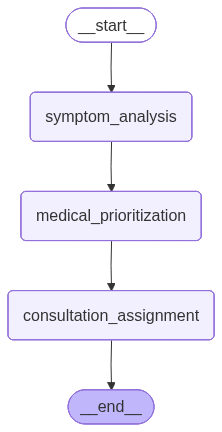

In [52]:
workflow

In [61]:
# TEST CASE 1 — REGULAR CONSULTATION

patient_1 = {
    "patient_name": "Arjun",
    "age": 28,
    "fever": 99,
    "oxygen_level": 98,
    "heart_rate": 80,
    "symptom_duration_days": 2,
    "existing_conditions": "None"
}

result_1 = workflow.invoke(patient_1)

print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_1.items():
    print(f"{key} : {value}")


========== STEP 1 : SYMPTOM ANALYSIS ==========
SEVERITY LEVEL : STABLE

========== STEP 2 : MEDICAL PRIORITIZATION ==========
CONSULTATION PRIORITY : REGULAR_CONSULTATION

========== STEP 3 : CONSULTATION ASSIGNMENT ==========
FINAL ASSIGNMENT : GENERAL PHYSICIAN

========== FINAL WORKFLOW OUTPUT ==========
patient_name : Arjun
age : 28
fever : 99
oxygen_level : 98
heart_rate : 80
symptom_duration_days : 2
existing_conditions : None
severity_level : STABLE
consultation_priority : REGULAR_CONSULTATION
consultation_assignment : GENERAL PHYSICIAN


In [60]:
# TEST CASE 2 — PRIORITY CONSULTATION

patient_2 = {
    "patient_name": "Meera",
    "age": 60,
    "fever": 102,
    "oxygen_level": 94,
    "heart_rate": 105,
    "symptom_duration_days": 6,
    "existing_conditions": "Diabetes"
}

result_2 = workflow.invoke(patient_2)

print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_2.items():
    print(f"{key} : {value}")


========== STEP 1 : SYMPTOM ANALYSIS ==========
SEVERITY LEVEL : MODERATE

========== STEP 2 : MEDICAL PRIORITIZATION ==========
CONSULTATION PRIORITY : PRIORITY_CONSULTATION

========== STEP 3 : CONSULTATION ASSIGNMENT ==========
FINAL ASSIGNMENT : SPECIALIST DOCTOR

========== FINAL WORKFLOW OUTPUT ==========
patient_name : Meera
age : 60
fever : 102
oxygen_level : 94
heart_rate : 105
symptom_duration_days : 6
existing_conditions : Diabetes
severity_level : MODERATE
consultation_priority : PRIORITY_CONSULTATION
consultation_assignment : SPECIALIST DOCTOR


In [59]:
# TEST CASE 3 — EMERGENCY

patient_3 = {
    "patient_name": "Ravi",
    "age": 72,
    "fever": 105,
    "oxygen_level": 85,
    "heart_rate": 145,
    "symptom_duration_days": 8,
    "existing_conditions": "Heart Disease"
}

result_3 = workflow.invoke(patient_3)

print("\n========== FINAL WORKFLOW OUTPUT ==========")
for key, value in result_3.items():
    print(f"{key} : {value}")


========== STEP 1 : SYMPTOM ANALYSIS ==========
SEVERITY LEVEL : CRITICAL

========== STEP 2 : MEDICAL PRIORITIZATION ==========
CONSULTATION PRIORITY : EMERGENCY

========== STEP 3 : CONSULTATION ASSIGNMENT ==========
FINAL ASSIGNMENT : ICU / ER

========== FINAL WORKFLOW OUTPUT ==========
patient_name : Ravi
age : 72
fever : 105
oxygen_level : 85
heart_rate : 145
symptom_duration_days : 8
existing_conditions : Heart Disease
severity_level : CRITICAL
consultation_priority : EMERGENCY
consultation_assignment : ICU / ER
